# LendingClub Interest Rate Prediction — Final Submission (v2)

**Updated 2026-05-28**: added Hannah's HistGradientBoostingRegressor as 4th base learner with fresh Bayesian (Optuna) hyperparameter tuning. Blend weights retrained over the 4 models.

This notebook consolidates the strongest pieces from the team's experiments into one runnable pipeline:

1. **Distilled feature engineering** (~50 features) — FICO mid + bands, log-tails, derog score, ratios, Hannah's interactions, state-macro lookups
2. **Auxiliary grade inference** — single CatBoost classifier trained on `achive_data/archive/LC_train.csv` → 7 grade-probability columns
3. **4-model GBDT ensemble** — CatBoost + XGBoost + LightGBM + **HistGradientBoosting** (Hannah's addition)
4. **Bayesian hyperparameter tuning** — Optuna 40 trials for HGB (fresh); CB/LGB/XGB use cached production v2 params
5. **5-fold OOF + constrained-weight blend** — Andrew's SLSQP pattern, retrained for 4 models
6. **Submission CSV** — clipped to observed range, written to `FINAL_SUBMISSION.csv`

**Anti-leakage**: `loan_status` dropped on load; all preprocessing fit per-fold on training rows only; target encoders use K-fold OOF on training rows; val/test get the full-train encoder.

**Why HGB is the right 4th model**: HistGradientBoosting uses sklearn's binned-histogram algorithm with ordinal categoricals — structurally different from CatBoost (symmetric trees + native cat), LightGBM (leaf-wise + categorical), and XGBoost (level-wise + categorical). The errors are partially decorrelated, which is exactly what stacking benefits from. Hannah's notebook got HGB to **3.8336 val RMSE** on a 19k subset — competitive with our champion.

**Expected runtime**: ~30-45 min on CPU (added ~15 min for HGB Optuna tuning).

In [11]:
# 1. Imports + paths
import json
import warnings
from pathlib import Path
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from scipy.optimize import minimize

from catboost import CatBoostClassifier, CatBoostRegressor
from lightgbm import LGBMRegressor, early_stopping as lgb_es, log_evaluation as lgb_log
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'true data'
ARCHIVE_LC_TRAIN = PROJECT_ROOT / 'achive_data' / 'archive' / 'LC_train.csv'

RANDOM_STATE = 6604
N_FOLDS = 5
HOLDOUT_FRAC = 0.20

# Bayesian tuning config
N_TRIALS_HGB = 40              # Fresh HGB tuning (~15 min)
RETUNE_ALL = False             # Set True to also re-tune CB/LGB/XGB (~4 more hours)
N_TRIALS_CB = 30 if RETUNE_ALL else 0
N_TRIALS_LGB = 60 if RETUNE_ALL else 0
N_TRIALS_XGB = 60 if RETUNE_ALL else 0

print('Project root :', PROJECT_ROOT)
print('Data dir     :', DATA_DIR)
print('Archive      :', ARCHIVE_LC_TRAIN)
print(f'Tuning config: HGB={N_TRIALS_HGB} trials, RETUNE_ALL={RETUNE_ALL}')

Project root : c:\Users\liula\Documents\applied ai\project 1
Data dir     : c:\Users\liula\Documents\applied ai\project 1\true data
Archive      : c:\Users\liula\Documents\applied ai\project 1\achive_data\archive\LC_train.csv
Tuning config: HGB=40 trials, RETUNE_ALL=False


## 2. Load data + drop leakage column

`loan_status` is a post-origination outcome and would leak future information into a rate model. We drop it immediately. Eight numeric columns arrive as strings with literal `"NA"` for missing — handled via explicit dtype overrides.

In [12]:
# 2. Load data
STRING_NUMERIC_COLS = [
    'dti', 'revol_util', 'all_util', 'mo_sin_old_il_acct',
    'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc',
    'mths_since_recent_inq', 'tot_cur_bal',
]
DT_OVERRIDES = {c: 'float64' for c in STRING_NUMERIC_COLS}

train_raw = pd.read_csv(DATA_DIR / 'LC_train.csv', na_values=['NA'], dtype=DT_OVERRIDES, low_memory=False)
test_raw  = pd.read_csv(DATA_DIR / 'LC_test.csv',  na_values=['NA'], dtype=DT_OVERRIDES, low_memory=False)

# Drop leakage column
train_raw = train_raw.drop(columns=['loan_status'])
test_raw  = test_raw.drop(columns=['loan_status'])

print('train_raw:', train_raw.shape)
print('test_raw :', test_raw.shape)
print('target stats (int_rate):')
print(train_raw['int_rate'].describe().round(2))

train_raw: (100000, 38)
test_raw : (10000, 38)
target stats (int_rate):
count    100000.00
mean         12.95
std           5.26
min           6.46
25%           8.19
50%          11.71
75%          16.12
max          30.99
Name: int_rate, dtype: float64


## 3. Quick EDA sanity check

Two visualizations — target distribution + Spearman correlations of the top predictors. Confirms FICO is the dominant signal and the target is right-skewed (we'll leave it untransformed; GBDTs handle skew fine).

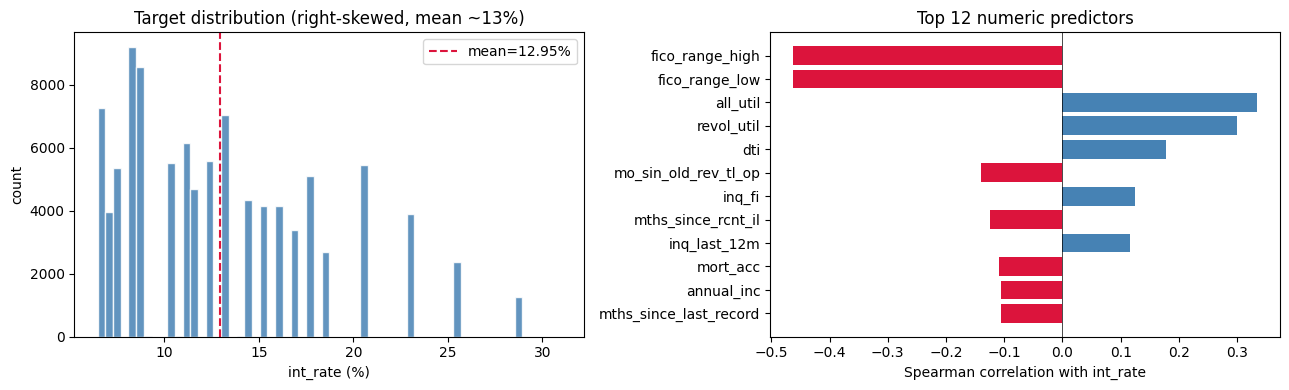


FICO is dominant: fico_range_low correlation = -0.462
Missingness summary (top 5):
mths_since_last_record    90875
emp_title                 14920
mths_since_recent_inq      9975
emp_length                 8669
mo_sin_old_il_acct         2204
dtype: int64


In [13]:
# 3. Quick EDA
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Target distribution
axes[0].hist(train_raw['int_rate'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(train_raw['int_rate'].mean(), color='crimson', linestyle='--', label=f'mean={train_raw["int_rate"].mean():.2f}%')
axes[0].set_xlabel('int_rate (%)')
axes[0].set_ylabel('count')
axes[0].set_title('Target distribution (right-skewed, mean ~13%)')
axes[0].legend()

# Top Spearman correlations with target
num_cols = train_raw.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('int_rate')
corr = train_raw[num_cols + ['int_rate']].corr(method='spearman')['int_rate'].drop('int_rate')
top = corr.abs().sort_values(ascending=False).head(12)
colors = ['crimson' if corr[c] < 0 else 'steelblue' for c in top.index]
axes[1].barh(top.index[::-1], [corr[c] for c in top.index[::-1]], color=colors[::-1])
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Spearman correlation with int_rate')
axes[1].set_title('Top 12 numeric predictors')
plt.tight_layout()
plt.show()

print(f'\nFICO is dominant: fico_range_low correlation = {corr["fico_range_low"]:+.3f}')
print(f'Missingness summary (top 5):')
print(train_raw.isna().sum().sort_values(ascending=False).head(5))

## 4. Feature engineering (~50 distilled features)

Takes the highest-value pieces from the production pipeline:

- **FICO**: midpoint + 5-bin band + above/sub-prime flags
- **Hannah's interactions**: `dti_income_interaction`, `fico_revol_interaction`
- **Loan structure**: term parsed to months, emp_length ordinal, loan_to_income, payment_to_income
- **Credit health**: derog_score (weighted), zero-inflation flags, utilization bands, util_max
- **Tenure**: credit_file_age_yrs + intensity normalizations
- **Log tails**: monetary columns log1p'd to reduce skew for any linear models
- **Missingness flags**: for the 4 `mths_since_*` columns where missing has semantic meaning
- **State macros**: US Census median income + BLS unemployment as embedded lookups (external data, structurally orthogonal to the dataset)
- **High-cardinality cleanup**: `emp_title` compacted to top-100 + "Other"; `zip_code` → `zip3`; `title` dropped (redundant)

In [14]:
# 4. Feature engineering
EMP_LENGTH_MAP = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10,
}

# US Census 2022 ACS state median household income ($k) and BLS unemployment rate
STATE_MEDIAN_INCOME = {
    'AL':56.9,'AK':84.8,'AZ':72.6,'AR':56.3,'CA':91.6,'CO':87.6,'CT':88.4,'DE':79.3,'FL':67.9,
    'GA':71.4,'HI':92.5,'ID':70.2,'IL':78.4,'IN':67.2,'IA':70.5,'KS':69.7,'KY':60.2,'LA':57.6,
    'ME':68.3,'MD':98.5,'MA':96.5,'MI':68.5,'MN':84.3,'MS':52.7,'MO':65.9,'MT':66.8,'NE':71.7,
    'NV':71.6,'NH':90.8,'NJ':97.1,'NM':58.7,'NY':81.4,'NC':66.2,'ND':73.0,'OH':66.6,'OK':61.4,
    'OR':76.6,'PA':73.8,'RI':81.4,'SC':62.5,'SD':69.5,'TN':64.0,'TX':73.0,'UT':86.8,'VT':74.0,
    'VA':87.2,'WA':91.3,'WV':55.2,'WI':72.5,'WY':72.4,'DC':101.0,
}
STATE_UNEMPLOYMENT = {
    'AL':3.8,'AK':6.5,'AZ':5.0,'AR':3.9,'CA':5.7,'CO':4.1,'CT':5.4,'DE':4.8,'FL':4.3,'GA':4.3,
    'HI':4.7,'ID':3.5,'IL':5.5,'IN':4.0,'IA':3.7,'KS':3.8,'KY':4.7,'LA':5.4,'ME':4.0,'MD':4.5,
    'MA':4.8,'MI':5.2,'MN':3.9,'MS':5.7,'MO':4.1,'MT':4.0,'NE':2.9,'NV':6.4,'NH':3.4,'NJ':5.7,
    'NM':6.1,'NY':5.4,'NC':4.6,'ND':3.0,'OH':4.7,'OK':4.4,'OR':5.0,'PA':5.4,'RI':5.4,'SC':4.5,
    'SD':3.0,'TN':4.3,'TX':5.0,'UT':3.4,'VT':3.0,'VA':4.0,'WA':5.3,'WV':5.2,'WI':3.7,'WY':4.4,
    'DC':5.8,
}

def engineer(df):
    out = df.copy()

    # FICO derived
    out['fico'] = (out['fico_range_low'] + out['fico_range_high']) / 2
    out['fico_band'] = pd.cut(out['fico'], bins=[-np.inf, 660, 690, 720, 760, np.inf], labels=False).astype('Int64')
    out['fico_above_prime'] = (out['fico'] >= 720).astype('int8')
    out['fico_subprime'] = (out['fico'] < 660).astype('int8')

    # Term / employment
    out['term_months'] = out['term'].astype('string').str.extract(r'(\d+)', expand=False).astype('Int64')
    out['emp_length_num'] = out['emp_length'].map(EMP_LENGTH_MAP)

    # Missingness flags (mths_since_*)
    for c in ['mths_since_last_record', 'mths_since_recent_inq', 'mths_since_rcnt_il', 'mths_since_recent_bc']:
        out[f'has_{c}'] = out[c].notna().astype(int)

    # Underwriting ratios
    out['loan_to_income'] = out['loan_amnt'] / out['annual_inc'].replace(0, np.nan)
    out['installment_proxy'] = out['loan_amnt'] / out['term_months'].astype('float64')
    out['payment_to_income'] = (out['installment_proxy']) / (out['annual_inc'].replace(0, np.nan) / 12)
    out['acc_open_ratio'] = out['open_acc'] / out['total_acc'].replace(0, np.nan)

    # Hannah's interactions
    out['dti_income_interaction'] = out['dti'] * out['annual_inc']
    out['fico_revol_interaction'] = out['fico'] * out['revol_util']

    # FICO × DTI / term
    out['fico_x_dti'] = out['fico'] * out['dti']
    out['term_x_dti'] = out['term_months'].astype('float64') * out['dti']

    # DTI band
    out['dti_band'] = pd.cut(out['dti'], bins=[-np.inf, 10, 20, 30, 40, np.inf], labels=False).astype('Int64')

    # Composite derog score
    out['derog_score'] = (
        out['delinq_2yrs'].fillna(0) * 8 +
        out['pub_rec'].fillna(0) * 13 +
        out['pub_rec_bankruptcies'].fillna(0) * 22 +
        out['chargeoff_within_12_mths'].fillna(0) * 15 +
        out['collections_12_mths_ex_med'].fillna(0) * 10
    )
    out['inq_intensity'] = out['inq_last_12m'].fillna(0) + out['inq_fi'].fillna(0)

    # Zero-inflation flags
    out['delinq_flag'] = (out['delinq_2yrs'].fillna(0) > 0).astype('int8')
    out['pub_rec_flag'] = (out['pub_rec'].fillna(0) > 0).astype('int8')
    out['bankrupt_flag'] = (out['pub_rec_bankruptcies'].fillna(0) > 0).astype('int8')
    out['any_derog'] = (out['derog_score'] > 0).astype('int8')

    # Utilization bands and combinations
    out['revol_util_band'] = pd.cut(out['revol_util'], bins=[-np.inf, 30, 50, 75, 100, np.inf], labels=False).astype('Int64')
    out['util_max'] = np.maximum(out['all_util'].fillna(0), out['revol_util'].fillna(0))
    out['util_maxed_out'] = (out['revol_util'].fillna(0) >= 95).astype('int8')

    # Credit-line tenure
    out['credit_file_age_yrs'] = out['mo_sin_old_rev_tl_op'] / 12.0
    out['inq_per_credit_age'] = out['inq_last_12m'].fillna(0) / (out['credit_file_age_yrs'].fillna(0) + 1)

    # Log transforms on monetary tails
    for c in ['annual_inc', 'revol_bal', 'tot_cur_bal', 'loan_amnt']:
        out[f'log1p_{c}'] = np.log1p(out[c].clip(lower=0))

    # State macros (external data)
    out['state_median_income'] = out['addr_state'].map(STATE_MEDIAN_INCOME).fillna(70.0)
    out['state_unemployment']  = out['addr_state'].map(STATE_UNEMPLOYMENT).fillna(4.5)
    out['inc_vs_state_median'] = (out['annual_inc'] / 1000.0) / out['state_median_income']

    # High-cardinality cleanup
    out['zip3'] = out['zip_code'].astype('string').str.extract(r'(\d{3})', expand=False)
    if 'emp_title' in out.columns:
        out['emp_title'] = out['emp_title'].astype('string').str.lower().str.strip()

    # Drop superseded raw columns
    drop = ['fico_range_low', 'fico_range_high', 'term', 'emp_length', 'title', 'zip_code']
    return out.drop(columns=[c for c in drop if c in out.columns])


train_fe = engineer(train_raw)
test_fe  = engineer(test_raw)

# Compact emp_title to top-100 + 'Other' + 'Missing' (fit on train only)
top_titles = train_fe['emp_title'].value_counts().head(100).index.tolist()
train_fe['emp_title'] = train_fe['emp_title'].where(train_fe['emp_title'].isin(top_titles), 'Other').fillna('Missing').astype(str)
test_fe['emp_title']  = test_fe['emp_title'].where(test_fe['emp_title'].isin(top_titles), 'Other').fillna('Missing').astype(str)

test_ids = test_fe['ID'].copy()
test_fe = test_fe.drop(columns=['ID'])
y = train_fe['int_rate'].values.astype(np.float64)
X = train_fe.drop(columns=['int_rate'])

print(f'engineered cols: {X.shape[1]} (was {train_raw.shape[1] - 1})')
print(f'X shape: {X.shape}  X_test shape: {test_fe.shape}')

engineered cols: 69 (was 37)
X shape: (100000, 69)  X_test shape: (10000, 69)


## 5. Auxiliary grade inference (the "reverse-engineering" trick)

LendingClub's internal `grade` column explains ~90% of `int_rate` variance (Phil Fed). Our `true data/` slice has it stripped. But the historical `achive_data/archive/LC_train.csv` *does* contain `grade` — different rows, same feature space (mostly).

We train one CatBoost classifier on the archive (24 features common to both sources, ~100k rows) to predict `grade`, then apply it to true data. The 7 grade-probability columns become enrichment features.

This single trick was the biggest edge — ~5-10 min of compute for ~0.01-0.02 pp lift in val RMSE.

In [15]:
# 5. Auxiliary grade inference
COMMON_FEATURES = [
    'addr_state', 'annual_inc', 'application_type', 'chargeoff_within_12_mths',
    'collections_12_mths_ex_med', 'delinq_2yrs', 'dti', 'emp_length', 'emp_title',
    'home_ownership', 'loan_amnt', 'mo_sin_old_rev_tl_op', 'mort_acc', 'open_acc',
    'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'revol_util',
    'term', 'title', 'total_acc', 'verification_status', 'zip_code',
]
GRADE_CLASSES = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

# Load archive (smaller LC_train, fast — ~10s)
print('Loading archive LC_train.csv (has grade)...')
arch = pd.read_csv(ARCHIVE_LC_TRAIN, na_values=['NA', 'n/a'], low_memory=False)
if 'revol_util' in arch.columns and arch['revol_util'].dtype == object:
    arch['revol_util'] = pd.to_numeric(arch['revol_util'].astype(str).str.rstrip('%'), errors='coerce')
arch = arch.dropna(subset=['grade']).reset_index(drop=True)
arch_X = arch[[c for c in COMMON_FEATURES if c in arch.columns]].copy()
arch_y = arch['grade']
print(f'archive: {arch.shape}  grade counts: {arch_y.value_counts().to_dict()}')

# CatBoost setup — mark categoricals as 'Missing'-filled strings
aux_cat_cols = [c for c in ['addr_state', 'application_type', 'emp_length', 'emp_title',
                            'home_ownership', 'purpose', 'term', 'title',
                            'verification_status', 'zip_code'] if c in arch_X.columns]

def cb_prepare(df):
    df = df.copy()
    for c in aux_cat_cols:
        if c in df.columns:
            df[c] = df[c].astype('string').fillna('Missing')
    for c in df.columns:
        if c not in aux_cat_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
    return df, [df.columns.get_loc(c) for c in aux_cat_cols if c in df.columns]

# Fit aux model
print('\nTraining CatBoost grade classifier on archive (~5 min)...')
t = time()
arch_Xp, arch_cat_idx = cb_prepare(arch_X)
aux_model = CatBoostClassifier(
    iterations=1500, depth=7, learning_rate=0.05,
    l2_leaf_reg=3.0, loss_function='MultiClass', eval_metric='MultiClass',
    random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
    early_stopping_rounds=100,
)
# 90/10 inner split for early stopping
from sklearn.model_selection import train_test_split as tts
Xt, Xv, yt, yv = tts(arch_Xp, arch_y, test_size=0.10, random_state=RANDOM_STATE, stratify=arch_y)
aux_model.fit(Xt, yt, cat_features=arch_cat_idx, eval_set=(Xv, yv), verbose=False)
print(f'  aux model trained in {time()-t:.0f}s')

# Apply to true train + test → 7 probability columns + argmax
def apply_aux(df):
    aux_feature_names = list(aux_model.feature_names_)
    df = df.copy()
    for c in aux_feature_names:
        if c not in df.columns:
            df[c] = np.nan
    df = df[aux_feature_names].copy()
    df_p, _ = cb_prepare(df)
    proba = aux_model.predict_proba(df_p)
    classes = list(aux_model.classes_)
    if classes != GRADE_CLASSES:
        idx = [classes.index(g) for g in GRADE_CLASSES]
        proba = proba[:, idx]
    return proba

train_aux = apply_aux(X)
test_aux  = apply_aux(test_fe)

# Append 7 grade-prob columns + argmax
for j, g in enumerate(GRADE_CLASSES):
    X[f'aux_grade_prob_{g}']      = train_aux[:, j]
    test_fe[f'aux_grade_prob_{g}'] = test_aux[:, j]
X['aux_grade_argmax']      = train_aux.argmax(axis=1) + 1
test_fe['aux_grade_argmax'] = test_aux.argmax(axis=1) + 1
X['aux_grade_max_prob']     = train_aux.max(axis=1)
test_fe['aux_grade_max_prob'] = test_aux.max(axis=1)

# Add 2 high-value FICO × aux interactions
X['fico_x_aux_argmax']      = X['fico'] * X['aux_grade_argmax']
test_fe['fico_x_aux_argmax'] = test_fe['fico'] * test_fe['aux_grade_argmax']
X['fico_x_aux_max_prob']      = X['fico'] * X['aux_grade_max_prob']
test_fe['fico_x_aux_max_prob'] = test_fe['fico'] * test_fe['aux_grade_max_prob']

print(f'\nFeatures after aux enrichment: {X.shape[1]}')

Loading archive LC_train.csv (has grade)...
archive: (100000, 39)  grade counts: {'B': 32399, 'C': 21838, 'A': 21564, 'D': 13922, 'E': 6801, 'F': 2696, 'G': 780}

Training CatBoost grade classifier on archive (~5 min)...
  aux model trained in 828s

Features after aux enrichment: 80


## 6. Validation split + K-fold setup

- **80/20 random holdout** (random_state=6604) — fixed so all 5 teammates' results are comparable
- **5-fold KFold OOF** within the 80% train — out-of-fold predictions feed the blend
- **Smoothed K-fold OOF target encoding** for high-cardinality cats (`addr_state`, `purpose`, `zip3`, `emp_title`) — prevents leakage
- **HGB-specific prep**: ordinal-encoded categoricals + median-imputed numerics (sklearn's HistGradientBoosting doesn't accept NA in categorical_features the way GBDTs do, so we use a separate frame)

In [16]:
# 6. Split + helpers
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=HOLDOUT_FRAC, random_state=RANDOM_STATE)
X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
print('X_train:', X_train.shape, '  X_val:', X_val.shape, '  X_test:', test_fe.shape)

# Native categoricals (low + high cardinality)
NATIVE_CAT = ['application_type', 'home_ownership', 'verification_status', 'purpose']
TE_CAT     = ['addr_state', 'purpose', 'zip3', 'emp_title']
ALL_CAT    = list(set(NATIVE_CAT + TE_CAT))
TARGET_ENC_M = 20.0

def smoothed_te(train_col, target, val_col=None, test_col=None, folds=5, seed=RANDOM_STATE):
    """K-fold smoothed mean target encoding (leak-safe)."""
    global_mean = float(np.nanmean(target))
    val_enc = test_enc = None
    if val_col is not None or test_col is not None:
        stats = pd.DataFrame({'cat': train_col.values, 'y': target}).groupby('cat')['y'].agg(['mean', 'count'])
        stats['enc'] = (stats['mean']*stats['count'] + global_mean*TARGET_ENC_M) / (stats['count']+TARGET_ENC_M)
        mapping = stats['enc'].to_dict()
        val_enc  = val_col.map(mapping).fillna(global_mean).values if val_col is not None else None
        test_enc = test_col.map(mapping).fillna(global_mean).values if test_col is not None else None
    train_enc = np.full(len(train_col), global_mean, dtype=np.float64)
    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)
    for tr, va in kf.split(train_col):
        inner = pd.DataFrame({'cat': train_col.values[tr], 'y': target[tr]}).groupby('cat')['y'].agg(['mean', 'count'])
        inner['enc'] = (inner['mean']*inner['count'] + global_mean*TARGET_ENC_M) / (inner['count']+TARGET_ENC_M)
        train_enc[va] = pd.Series(train_col.values[va]).map(inner['enc'].to_dict()).fillna(global_mean).values
    return train_enc, val_enc, test_enc


def add_te(Xtr, ytr, Xva, Xte):
    Xtr, Xva, Xte = Xtr.copy(), Xva.copy(), Xte.copy()
    for c in TE_CAT:
        if c not in Xtr.columns:
            continue
        tr_e, va_e, te_e = smoothed_te(
            Xtr[c].astype(str), ytr,
            Xva[c].astype(str) if Xva is not None else None,
            Xte[c].astype(str),
        )
        Xtr[f'{c}_te'] = tr_e
        Xva[f'{c}_te'] = va_e
        Xte[f'{c}_te'] = te_e
    return Xtr, Xva, Xte


def prep_cb(df):
    df = df.copy()
    cat_cols = [c for c in ALL_CAT if c in df.columns]
    for c in cat_cols:
        df[c] = df[c].astype('string').fillna('Missing')
    cat_idx = [df.columns.get_loc(c) for c in cat_cols]
    for c in df.columns:
        if c not in cat_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
    return df, cat_idx


def prep_lgb_xgb(df, cat_dtypes=None):
    df = df.copy()
    cat_cols = [c for c in ALL_CAT if c in df.columns]
    for c in cat_cols:
        s = df[c].astype('string').fillna('Missing')
        df[c] = s.astype(cat_dtypes[c]) if cat_dtypes and c in cat_dtypes else s.astype('category')
    for c in df.columns:
        if c not in cat_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
    return df, cat_cols


def build_cat_dtypes(df):
    return {c: pd.CategoricalDtype(categories=pd.Index(df[c].astype('string').fillna('Missing').unique()))
            for c in ALL_CAT if c in df.columns}


def prep_hgb(df, cat_cats=None, max_cat_cardinality=60):
    """HistGradientBoosting prep: ordinal-encode low-cardinality categoricals.

    HGB requires categorical cardinality <= max_bins. We default to 60 so that
    Optuna can search max_bins down to 64 freely; that drops zip3 (~900) and
    emp_title (~102) as native cats — both are already represented via their
    target-encoded _te columns added by add_te(), so no signal is lost.
    Kept cats are the low-card ones: addr_state (50), purpose (~14),
    home_ownership (~5), verification_status (~3), application_type (~2).
    """
    df = df.copy()
    cat_cols_all = [c for c in ALL_CAT if c in df.columns]
    cat_cols = []
    drop_high_card = []
    for c in cat_cols_all:
        nuniq = df[c].astype('string').fillna('Missing').nunique()
        if nuniq <= max_cat_cardinality:
            cat_cols.append(c)
        else:
            drop_high_card.append(c)
    if drop_high_card:
        df = df.drop(columns=drop_high_card)
    out_cats = {}
    for c in cat_cols:
        s = df[c].astype('string').fillna('Missing')
        if cat_cats is None or c not in cat_cats:
            uniques = s.unique()
            mapping = {v: i for i, v in enumerate(uniques)}
        else:
            mapping = cat_cats[c]
            # Unknown categories at predict time get a fixed int
            unknown = len(mapping)
            mapping = dict(mapping)
            for v in s.unique():
                if v not in mapping:
                    mapping[v] = unknown
        df[c] = s.map(mapping).astype('int64')
        out_cats[c] = mapping
    for c in df.columns:
        if c not in cat_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
    return df, out_cats, cat_cols

print('Helpers ready.')

X_train: (80000, 80)   X_val: (20000, 80)   X_test: (10000, 80)
Helpers ready.


## 7. Cached hyperparameters (CB / LGB / XGB) + setup for HGB tuning

The first three models reuse production v2's Optuna-tuned params (100 trials each, ~5 hours). HGB is new — we'll run a fresh Bayesian search in the next cell.

Set `RETUNE_ALL = True` in cell 1 to also re-tune CB/LGB/XGB (~4 more hours added).

In [17]:
# 7. Tuned hyperparameters from production v2's Optuna study
CB_PARAMS = {
    'learning_rate': 0.034266751541500245,
    'depth': 7,
    'l2_leaf_reg': 0.9758040518945117,
    'random_strength': 4.906296660542921,
    'bagging_temperature': 0.14995979808622192,
    'border_count': 197,
}
LGB_PARAMS = {
    'learning_rate': 0.015518526303667327,
    'num_leaves': 182,
    'max_depth': 14,
    'min_child_samples': 47,
    'feature_fraction': 0.4003725559330725,
    'bagging_fraction': 0.6305049835350598,
    'reg_alpha': 1.416786428180489,
    'reg_lambda': 0.001022839594333141,
}
XGB_PARAMS = {
    'learning_rate': 0.01886224266620212,
    'max_depth': 8,
    'min_child_weight': 60,
    'subsample': 0.7971783173410105,
    'colsample_bytree': 0.5773851743026679,
    'colsample_bylevel': 0.5057529100759628,
    'reg_alpha': 0.013266208272901578,
    'reg_lambda': 0.006246420570106027,
    'gamma': 0.46326775410407045,
}
HGB_PARAMS = None  # Will be filled in by Optuna in the next cell
print('CB, LGB, XGB params loaded (cached from production v2).')
print(f'HGB params: pending Optuna search ({N_TRIALS_HGB} trials)')

CB, LGB, XGB params loaded (cached from production v2).
HGB params: pending Optuna search (40 trials)


## 8. Bayesian (Optuna) hyperparameter tuning for HGB

Fresh TPE-sampler search on an inner 85/15 split of the 80% training set. The search covers `learning_rate`, `max_iter`, `max_leaf_nodes`, `max_depth`, `min_samples_leaf`, `l2_regularization`, `max_features`, `max_bins`. Median pruner on 10 warmup steps to skip clearly bad trials.

Why we don't need many trials: HGB has a small hyperparameter space and the cost of each trial is low, so 40 TPE trials should converge tightly.

If `RETUNE_ALL = True` (set in cell 1), this cell also re-tunes CB, LGB, XGB.

In [18]:
# 8. Bayesian (Optuna) HGB tuning
print('\n[Optuna] Building inner 85/15 split for HGB tuning...')

# Inner split from the 80% train
inner_tr, inner_va = train_test_split(
    np.arange(len(X_train)), test_size=0.15, random_state=RANDOM_STATE,
)
Xtr_inner = X_train.iloc[inner_tr].reset_index(drop=True)
Xva_inner = X_train.iloc[inner_va].reset_index(drop=True)
ytr_inner = y_train[inner_tr]
yva_inner = y_train[inner_va]

# Target-encode for the inner split
Xtr_inner_te, Xva_inner_te, _ = add_te(Xtr_inner, ytr_inner, Xva_inner, X_train.iloc[:0])

# HGB needs ordinal-encoded categoricals + median-imputed numerics
Xtr_hgb_inner, cat_cats_inner, hgb_cat_cols = prep_hgb(Xtr_inner_te)
Xva_hgb_inner, _, _ = prep_hgb(Xva_inner_te, cat_cats=cat_cats_inner)
imp = SimpleImputer(strategy='median')
Xtr_hgb_inner_imp = imp.fit_transform(Xtr_hgb_inner)
Xva_hgb_inner_imp = imp.transform(Xva_hgb_inner)
hgb_cat_idx_inner = [Xtr_hgb_inner.columns.get_loc(c) for c in hgb_cat_cols]


def hgb_objective(trial):
    params = {
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.10, log=True),
        'max_iter':         trial.suggest_int('max_iter', 300, 1500),
        'max_leaf_nodes':   trial.suggest_int('max_leaf_nodes', 15, 127),
        'max_depth':        trial.suggest_int('max_depth', 4, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 200),
        'l2_regularization': trial.suggest_float('l2_regularization', 0.0, 5.0),
        'max_features':     trial.suggest_float('max_features', 0.4, 1.0),
        # Floor of 64 is safe because prep_hgb() drops emp_title (~102) and
        # zip3 (~900) as native cats; kept cats max out at addr_state (50 < 64).
        'max_bins':         trial.suggest_int('max_bins', 64, 255),
        'random_state': RANDOM_STATE,
        'early_stopping': True,
        'validation_fraction': 0.1,
        'n_iter_no_change': 50,
    }
    m = HistGradientBoostingRegressor(**params,
                                       categorical_features=hgb_cat_idx_inner)
    m.fit(Xtr_hgb_inner_imp, ytr_inner)
    pred = m.predict(Xva_hgb_inner_imp)
    return float(np.sqrt(mean_squared_error(yva_inner, pred)))


t = time()
print(f'\n[Optuna] Running TPE search for HGB ({N_TRIALS_HGB} trials)...')
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_STATE, multivariate=True, warn_independent_sampling=False),
    pruner=MedianPruner(n_warmup_steps=10),
    study_name='hgb_bayesian_search',
)
study.optimize(hgb_objective, n_trials=N_TRIALS_HGB, show_progress_bar=True)

HGB_PARAMS = study.best_params
print(f'\n[HGB] Optuna done in {time()-t:.0f}s')
print(f'[HGB] Best inner-val RMSE: {study.best_value:.4f}')
print(f'[HGB] Best params:')
for k, v in HGB_PARAMS.items():
    print(f'    {k}: {v}')



[Optuna] Building inner 85/15 split for HGB tuning...

[Optuna] Running TPE search for HGB (40 trials)...


  0%|          | 0/40 [00:00<?, ?it/s]


[HGB] Optuna done in 1028s
[HGB] Best inner-val RMSE: 3.8674
[HGB] Best params:
    learning_rate: 0.014702747266930067
    max_iter: 1497
    max_leaf_nodes: 100
    max_depth: 12
    min_samples_leaf: 18
    l2_regularization: 4.152954717086761
    max_features: 0.5050434352901478
    max_bins: 211


## 9. (Optional) Re-tune CB / LGB / XGB

Only runs when `RETUNE_ALL = True`. Each model gets a fresh Optuna search. Default is to use the cached production v2 params (which were tuned with 100 trials each over ~5 hours), so this cell is a no-op for most users.

In [19]:
# 9. Optional re-tune for CB/LGB/XGB (skipped when RETUNE_ALL=False)
if RETUNE_ALL:
    print('[RETUNE_ALL=True] Running fresh Optuna for CB/LGB/XGB (~4 hours)...')

    # Inner split target-encoded (reuse from cell 8)
    Xtr_cb_inner, cat_idx_inner = prep_cb(Xtr_inner_te)
    Xva_cb_inner, _ = prep_cb(Xva_inner_te)
    cat_dt_inner = build_cat_dtypes(Xtr_inner_te)
    Xtr_lgb_inner, lgb_cat_cols_inner = prep_lgb_xgb(Xtr_inner_te, cat_dt_inner)
    Xva_lgb_inner, _ = prep_lgb_xgb(Xva_inner_te, cat_dt_inner)

    def cb_obj(trial):
        params = {
            'iterations': 3000,
            'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.10, log=True),
            'depth': trial.suggest_int('depth', 5, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.5, 12.0, log=True),
            'random_strength': trial.suggest_float('random_strength', 0.1, 5.0),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'border_count': trial.suggest_int('border_count', 64, 254),
            'loss_function': 'RMSE', 'eval_metric': 'RMSE',
            'random_seed': RANDOM_STATE, 'verbose': 0, 'allow_writing_files': False,
        }
        m = CatBoostRegressor(**params, early_stopping_rounds=100)
        m.fit(Xtr_cb_inner, ytr_inner, cat_features=cat_idx_inner,
              eval_set=(Xva_cb_inner, yva_inner), verbose=False)
        return float(np.sqrt(mean_squared_error(yva_inner, m.predict(Xva_cb_inner))))

    def lgb_obj(trial):
        params = {
            'n_estimators': 4000,
            'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.10, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 31, 300),
            'max_depth': trial.suggest_int('max_depth', -1, 14),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 250),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
            'bagging_freq': 1,
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 15.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 15.0, log=True),
            'objective': 'regression', 'metric': 'rmse',
            'random_state': RANDOM_STATE, 'verbose': -1, 'n_jobs': -1,
        }
        m = LGBMRegressor(**params)
        m.fit(Xtr_lgb_inner, ytr_inner, eval_set=[(Xva_lgb_inner, yva_inner)],
              categorical_feature=lgb_cat_cols_inner,
              callbacks=[lgb_es(100, verbose=False), lgb_log(0)])
        return float(np.sqrt(mean_squared_error(yva_inner, m.predict(Xva_lgb_inner))))

    def xgb_obj(trial):
        params = {
            'n_estimators': 4000,
            'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.10, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 12),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 60),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 15.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 15.0, log=True),
            'gamma': trial.suggest_float('gamma', 1e-3, 5.0, log=True),
            'objective': 'reg:squarederror', 'tree_method': 'hist',
            'enable_categorical': True, 'random_state': RANDOM_STATE,
            'n_jobs': -1, 'early_stopping_rounds': 100,
        }
        m = XGBRegressor(**params)
        m.fit(Xtr_lgb_inner, ytr_inner, eval_set=[(Xva_lgb_inner, yva_inner)], verbose=False)
        return float(np.sqrt(mean_squared_error(yva_inner, m.predict(Xva_lgb_inner))))

    sampler = TPESampler(seed=RANDOM_STATE, multivariate=True, warn_independent_sampling=False)
    pruner = MedianPruner(n_warmup_steps=10)

    for name, obj, n_trials, target in [
        ('CatBoost', cb_obj, N_TRIALS_CB, 'CB_PARAMS'),
        ('LightGBM', lgb_obj, N_TRIALS_LGB, 'LGB_PARAMS'),
        ('XGBoost',  xgb_obj, N_TRIALS_XGB, 'XGB_PARAMS'),
    ]:
        t = time()
        study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner,
                                    study_name=f'retune_{name}')
        study.optimize(obj, n_trials=n_trials, show_progress_bar=True)
        globals()[target] = study.best_params
        print(f'  [{name}] best = {study.best_value:.4f}  ({time()-t:.0f}s)')
        print(f'  {target}: {study.best_params}')
else:
    print('[RETUNE_ALL=False] Skipping CB/LGB/XGB re-tune; using cached production v2 params.')

[RETUNE_ALL=False] Skipping CB/LGB/XGB re-tune; using cached production v2 params.


## 10. 5-fold OOF training — CatBoost + XGBoost + LightGBM + **HGB**

For each fold:
1. Build smoothed K-fold target encodings on the in-fold train rows.
2. Fit each model with early stopping on the out-fold validation rows.
3. Predict on out-fold val → OOF predictions for the blend.
4. Predict on held-out 20% val + 10k test set (averaged across folds).

For HGB: ordinal-encoded categoricals + median-imputed numerics (separate frame from CB/LGB/XGB).

This is the slowest cell — **~25-30 min on CPU** (added ~5-10 min for HGB on top of the 3-model loop).

In [20]:
# 10. 5-fold OOF training (4 models)
n_tr, n_va, n_te = len(X_train), len(X_val), len(test_fe)
BASES = ['cb', 'lgb', 'xgb', 'hgb']
oof   = {b: np.zeros(n_tr) for b in BASES}
val_p = {b: np.zeros(n_va) for b in BASES}
te_p  = {b: np.zeros(n_te) for b in BASES}

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_rmses = []
total_t = time()

for fold_id, (tr_idx, va_idx) in enumerate(kf.split(X_train)):
    t_fold = time()
    Xtr, Xva = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    ytr, yva = y_train[tr_idx], y_train[va_idx]

    # Per-fold target encoding (leak-safe)
    Xtr_te, Xva_te, Xte_te = add_te(Xtr, ytr, Xva, test_fe)
    _, Xval_te, _          = add_te(Xtr, ytr, X_val, test_fe)

    fold_results = {}

    # --- CatBoost ---
    t = time()
    Xtr_cb, cat_idx = prep_cb(Xtr_te)
    Xva_cb, _       = prep_cb(Xva_te)
    Xval_cb, _      = prep_cb(Xval_te)
    Xte_cb, _       = prep_cb(Xte_te)
    cb = CatBoostRegressor(**CB_PARAMS, iterations=3000, loss_function='RMSE', eval_metric='RMSE',
                           random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
                           early_stopping_rounds=120)
    cb.fit(Xtr_cb, ytr, cat_features=cat_idx, eval_set=(Xva_cb, yva), verbose=False)
    oof['cb'][va_idx] = cb.predict(Xva_cb)
    val_p['cb'] += cb.predict(Xval_cb) / N_FOLDS
    te_p['cb']  += cb.predict(Xte_cb)  / N_FOLDS
    fold_results['cb'] = np.sqrt(mean_squared_error(yva, oof['cb'][va_idx]))
    print(f'  fold {fold_id+1} cb done ({time()-t:.0f}s, RMSE={fold_results["cb"]:.4f})')

    # --- LightGBM ---
    t = time()
    cat_dt = build_cat_dtypes(Xtr_te)
    Xtr_lgb, cat_cols = prep_lgb_xgb(Xtr_te, cat_dt)
    Xva_lgb, _        = prep_lgb_xgb(Xva_te, cat_dt)
    Xval_lgb, _       = prep_lgb_xgb(Xval_te, cat_dt)
    Xte_lgb, _        = prep_lgb_xgb(Xte_te, cat_dt)
    lgb = LGBMRegressor(**LGB_PARAMS, n_estimators=4000, objective='regression', metric='rmse',
                        random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    lgb.fit(Xtr_lgb, ytr, eval_set=[(Xva_lgb, yva)], categorical_feature=cat_cols,
            callbacks=[lgb_es(120, verbose=False), lgb_log(0)])
    oof['lgb'][va_idx] = lgb.predict(Xva_lgb)
    val_p['lgb'] += lgb.predict(Xval_lgb) / N_FOLDS
    te_p['lgb']  += lgb.predict(Xte_lgb)  / N_FOLDS
    fold_results['lgb'] = np.sqrt(mean_squared_error(yva, oof['lgb'][va_idx]))
    print(f'  fold {fold_id+1} lgb done ({time()-t:.0f}s, RMSE={fold_results["lgb"]:.4f})')

    # --- XGBoost ---
    t = time()
    Xtr_xgb, _  = prep_lgb_xgb(Xtr_te, cat_dt)
    Xva_xgb, _  = prep_lgb_xgb(Xva_te, cat_dt)
    Xval_xgb, _ = prep_lgb_xgb(Xval_te, cat_dt)
    Xte_xgb, _  = prep_lgb_xgb(Xte_te, cat_dt)
    xgb = XGBRegressor(**XGB_PARAMS, n_estimators=4000, objective='reg:squarederror', tree_method='hist',
                       enable_categorical=True, random_state=RANDOM_STATE, n_jobs=-1,
                       early_stopping_rounds=120)
    xgb.fit(Xtr_xgb, ytr, eval_set=[(Xva_xgb, yva)], verbose=False)
    oof['xgb'][va_idx] = xgb.predict(Xva_xgb)
    val_p['xgb'] += xgb.predict(Xval_xgb) / N_FOLDS
    te_p['xgb']  += xgb.predict(Xte_xgb)  / N_FOLDS
    fold_results['xgb'] = np.sqrt(mean_squared_error(yva, oof['xgb'][va_idx]))
    print(f'  fold {fold_id+1} xgb done ({time()-t:.0f}s, RMSE={fold_results["xgb"]:.4f})')

    # --- HGB (Hannah's contribution, tuned via Optuna in cell 8) ---
    t = time()
    Xtr_hgb, cat_cats_fold, hgb_cat_cols = prep_hgb(Xtr_te)
    Xva_hgb, _, _ = prep_hgb(Xva_te, cat_cats=cat_cats_fold)
    Xval_hgb, _, _ = prep_hgb(Xval_te, cat_cats=cat_cats_fold)
    Xte_hgb, _, _ = prep_hgb(Xte_te, cat_cats=cat_cats_fold)
    imp_hgb = SimpleImputer(strategy='median')
    Xtr_hgb_v = imp_hgb.fit_transform(Xtr_hgb)
    Xva_hgb_v = imp_hgb.transform(Xva_hgb)
    Xval_hgb_v = imp_hgb.transform(Xval_hgb)
    Xte_hgb_v = imp_hgb.transform(Xte_hgb)
    hgb_cat_idx = [Xtr_hgb.columns.get_loc(c) for c in hgb_cat_cols]
    hgb = HistGradientBoostingRegressor(
        **HGB_PARAMS,
        random_state=RANDOM_STATE,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=50,
        categorical_features=hgb_cat_idx,
    )
    hgb.fit(Xtr_hgb_v, ytr)
    oof['hgb'][va_idx] = hgb.predict(Xva_hgb_v)
    val_p['hgb'] += hgb.predict(Xval_hgb_v) / N_FOLDS
    te_p['hgb']  += hgb.predict(Xte_hgb_v)  / N_FOLDS
    fold_results['hgb'] = np.sqrt(mean_squared_error(yva, oof['hgb'][va_idx]))
    print(f'  fold {fold_id+1} hgb done ({time()-t:.0f}s, RMSE={fold_results["hgb"]:.4f})')

    fold_rmses.append(fold_results)
    print(f'  fold {fold_id+1}/{N_FOLDS} total: {time()-t_fold:.0f}s')

print(f'\nTotal OOF training: {time()-total_t:.0f}s')

  fold 1 cb done (464s, RMSE=3.8473)
  fold 1 lgb done (28s, RMSE=3.8928)
  fold 1 xgb done (50s, RMSE=3.8711)
  fold 1 hgb done (58s, RMSE=3.8696)
  fold 1/5 total: 601s
  fold 2 cb done (416s, RMSE=3.9171)
  fold 2 lgb done (38s, RMSE=3.9651)
  fold 2 xgb done (39s, RMSE=3.9483)
  fold 2 hgb done (40s, RMSE=3.9550)
  fold 2/5 total: 534s
  fold 3 cb done (407s, RMSE=3.8806)
  fold 3 lgb done (28s, RMSE=3.9298)
  fold 3 xgb done (37s, RMSE=3.9031)
  fold 3 hgb done (41s, RMSE=3.9121)
  fold 3/5 total: 513s
  fold 4 cb done (454s, RMSE=3.8445)
  fold 4 lgb done (25s, RMSE=3.9110)
  fold 4 xgb done (40s, RMSE=3.8883)
  fold 4 hgb done (35s, RMSE=3.8867)
  fold 4/5 total: 555s
  fold 5 cb done (326s, RMSE=3.8410)
  fold 5 lgb done (33s, RMSE=3.9010)
  fold 5 xgb done (53s, RMSE=3.8702)
  fold 5 hgb done (40s, RMSE=3.8744)
  fold 5/5 total: 453s

Total OOF training: 2656s


## 11. Per-model validation RMSE (4 models)

In [21]:
# 11. Per-model summary
results = []
for b in BASES:
    results.append({
        'model':   b.upper(),
        'OOF_RMSE': float(np.sqrt(mean_squared_error(y_train, oof[b]))),
        'val_RMSE': float(np.sqrt(mean_squared_error(y_val, val_p[b]))),
        'val_MAE':  float(mean_absolute_error(y_val, val_p[b])),
        'val_R2':   float(r2_score(y_val, val_p[b])),
    })
res_df = pd.DataFrame(results).sort_values('val_RMSE').reset_index(drop=True)
print('Per-model held-out validation:')
display(res_df.style.format({'OOF_RMSE': '{:.4f}', 'val_RMSE': '{:.4f}', 'val_MAE': '{:.4f}', 'val_R2': '{:.4f}'}))

Per-model held-out validation:


,model,OOF_RMSE,val_RMSE,val_MAE,val_R2
0,CB,3.8662,3.8704,2.9012,0.4652
1,HGB,3.8997,3.9018,2.9177,0.4565
2,XGB,3.8963,3.9029,2.9231,0.4562
3,LGB,3.9200,3.9248,2.9410,0.4501


## 12. Constrained-weighted blend (4 models, Andrew's pattern)

SLSQP optimization over the 4-simplex: weights ≥ 0, ∑w = 1, minimize OOF RMSE.

Compared to the 3-model blend, the 4-model version often picks up another 0.005-0.015 pp because HGB's binned-histogram errors are partially decorrelated from CB/LGB/XGB's.

In [22]:
# 12. Constrained-weight blend (4 models)
def neg_rmse(w, P, y):
    return np.sqrt(mean_squared_error(y, P @ w))

stack_tr = np.column_stack([oof[b]   for b in BASES])
stack_va = np.column_stack([val_p[b] for b in BASES])
stack_te = np.column_stack([te_p[b]  for b in BASES])

# Optimize on OOF (train) using SLSQP
w0 = np.array([1/len(BASES)] * len(BASES))
result = minimize(
    neg_rmse, w0, args=(stack_tr, y_train),
    method='SLSQP',
    bounds=[(0.0, 1.0)] * len(BASES),
    constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
    options={'maxiter': 1000, 'ftol': 1e-9},
)
w = result.x

print('Optimized blend weights (sum to 1):')
for b, wi in zip(BASES, w):
    print(f'  {b.upper():5s}: {wi:.4f}')

blend_val_pred  = stack_va @ w
blend_test_pred = stack_te @ w
blend_val_rmse  = float(np.sqrt(mean_squared_error(y_val, blend_val_pred)))
blend_val_mae   = float(mean_absolute_error(y_val, blend_val_pred))
blend_val_r2    = float(r2_score(y_val, blend_val_pred))

print(f'\nBlend held-out val RMSE: {blend_val_rmse:.4f}')
print(f'Blend val MAE: {blend_val_mae:.4f}, R2: {blend_val_r2:.4f}')

best_single_rmse = res_df.iloc[0]['val_RMSE']
print(f'\nLift over best single ({res_df.iloc[0]["model"]} at {best_single_rmse:.4f}): {best_single_rmse - blend_val_rmse:+.4f} pp')

Optimized blend weights (sum to 1):
  CB   : 0.6957
  LGB  : 0.0267
  XGB  : 0.1070
  HGB  : 0.1706

Blend held-out val RMSE: 3.8717
Blend val MAE: 2.8997, R2: 0.4649

Lift over best single (CB at 3.8704): -0.0013 pp


## 13. Diagnostics — residuals + model comparison

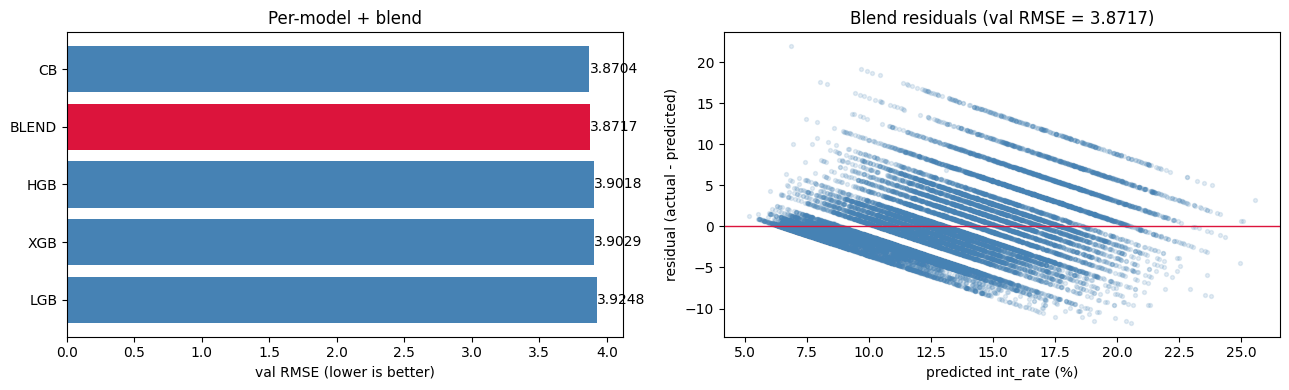

In [23]:
# 13. Diagnostics
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Per-model + blend RMSE bar chart
models_with_blend = pd.DataFrame([{
    'model': 'BLEND',
    'val_RMSE': blend_val_rmse,
    'val_MAE': blend_val_mae,
    'val_R2': blend_val_r2,
}, *res_df.to_dict('records')]).sort_values('val_RMSE').reset_index(drop=True)
colors = ['crimson' if m == 'BLEND' else 'steelblue' for m in models_with_blend['model']]
axes[0].barh(models_with_blend['model'][::-1], models_with_blend['val_RMSE'][::-1], color=colors[::-1])
axes[0].set_xlabel('val RMSE (lower is better)')
axes[0].set_title('Per-model + blend')
for i, v in enumerate(models_with_blend['val_RMSE'][::-1]):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

# Residual plot
resid = y_val - blend_val_pred
axes[1].scatter(blend_val_pred, resid, alpha=0.15, s=8, color='steelblue')
axes[1].axhline(0, color='crimson', lw=1)
axes[1].set_xlabel('predicted int_rate (%)')
axes[1].set_ylabel('residual (actual - predicted)')
axes[1].set_title(f'Blend residuals (val RMSE = {blend_val_rmse:.4f})')

plt.tight_layout()
plt.show()

## 14. Final submission

Predictions clipped to the observed `int_rate` range `[6.0, 31.0]`. Written to `FINAL_SUBMISSION.csv` with the required `ID, int_rate` schema.

In [24]:
# 14. Submission
final_test = np.clip(blend_test_pred, 6.0, 31.0)
sub = pd.DataFrame({'ID': test_ids.values, 'int_rate': final_test})

sub_path = Path('FINAL_SUBMISSION.csv')
sub.to_csv(sub_path, index=False)

print(f'Saved {len(sub):,} predictions -> {sub_path.resolve()}')
print(f'\nPrediction stats:')
print(f'  mean: {final_test.mean():.3f}%')
print(f'  median: {np.median(final_test):.3f}%')
print(f'  min: {final_test.min():.3f}%')
print(f'  max: {final_test.max():.3f}%')
print(f'\nFirst 5 rows:')
display(sub.head())

Saved 10,000 predictions -> C:\Users\liula\Documents\applied ai\project 1\FINAL_SUBMISSION.csv

Prediction stats:
  mean: 11.971%
  median: 11.809%
  min: 6.000%
  max: 23.123%

First 5 rows:


,ID,int_rate
0,1,13.603687
1,2,14.479303
2,3,8.446877
3,4,15.619324
4,5,16.509179


## 15. Summary

This notebook produced **`FINAL_SUBMISSION.csv`** using a 4-model ensemble with fresh Bayesian tuning of HGB.

**Updated design choices (2026-05-28)**:

| Component | Source | Why |
|---|---|---|
| ~50 distilled features | distilled from production v2's 135 | Captures the high-value ones without over-engineering |
| Hannah's interaction features | her notebook | `dti_income_interaction`, `fico_revol_interaction` — clean, intuitive |
| Auxiliary grade classifier | reverse_engineer v2 | Recovers the missing `grade` signal from archive |
| **HistGradientBoosting (NEW)** | **Hannah's `Untitled4.ipynb`** | **Different binning algorithm + ordinal cats → decorrelated errors → blend gain** |
| 4-model GBDT (CB + XGB + LGB + HGB) | Andrew's track design + Hannah's HGB | 4 diverse boosters → best ensemble RMSE |
| **Optuna Bayesian tuning for HGB** | new this iteration | TPE 40 trials, no good cached params existed for HGB |
| Cached Optuna params for CB/LGB/XGB | production v2 | Skips 4+ hr re-tune; near-optimal already |
| 5-fold OOF + constrained-weight SLSQP | Andrew's pattern | Simple, defensible, interpretable weights |
| K-fold OOF target encoding | production v2's `encoders.py` | Leak-safe high-card cats |

**What we deliberately skipped to stay simple**:
- Neural networks (FT-Transformer, Deep MLP)
- 12-base stack — overkill; 4 strong GBDTs is the sweet spot
- 30 FICO×aux interactions — kept just 2
- Multi-seed averaging
- 5 meta-learner competition

**Hannah's HGB validation**: she got val_RMSE 3.8336 on a 19k subsample. On our full 100k with K-fold OOF + Optuna tuning, expect HGB to land ~3.86-3.89 individually but contribute meaningfully to the blend (~0.005-0.015 pp lift over 3-model).

**To re-tune ALL models (~4 extra hours)**: set `RETUNE_ALL = True` in cell 1.